L'objectif de notre modèle est de prédire le résultat des matchs de ligue 1 de la saison 2023. Pour cela nous disposons 7 csv: clubs_fr qui contient les infos sur chaque équipe (stade, age moyen, etc), game_events contient chaque évenements de chaque matchs (buts, cartons, etc), game_lineups contient les compositions des équipes pour chaque match, match_2023 est la liste des matchs que l'on doit prédire, matchs_2013_2022 contient le résultat de chaque match (nombres de buts, gagnant,classement avant match, etc), player_appearance contient la performance d'un joueur lors d'une apparition et enfin player_valuation contient la valeur marchande des joueurs.
Beaucoup des données présentes dans les csv sont inutiles ou difficilement exploitables comme éléments de prédiction comme game_lineup par exemple. Nous avons donc décidé de nous concentrer majoritairement dans un premier temps sur le csv matchs_2013_2022 qui contient le résultat et la majorité des données numériques intéressantes. 

Nous réalisons tout d'abord une heatmap pour avoir une première idée de quelles données sont corrélées.

   Unnamed: 0  game_id  season         round        date  home_club_id  \
0          12  2330874    2013   8. Matchday  2013-09-28           618   
1          13  2330880    2013  10. Matchday  2013-10-19         14171   
2          14  2330916    2013  15. Matchday  2013-11-30          1423   
3          15  2331018    2013  21. Matchday  2014-01-18           273   
4          16  2331034    2013  24. Matchday  2014-02-08          1147   

   away_club_id  home_club_goals  away_club_goals  home_club_position  ...  \
0           595                2                2                 6.0  ...   
1           855                1                2                16.0  ...   
2          1082                0                1                18.0  ...   
3         14171                0                0                15.0  ...   
4           273                3                1                20.0  ...   

                    stadium attendance            referee home_club_formation  \
0   S

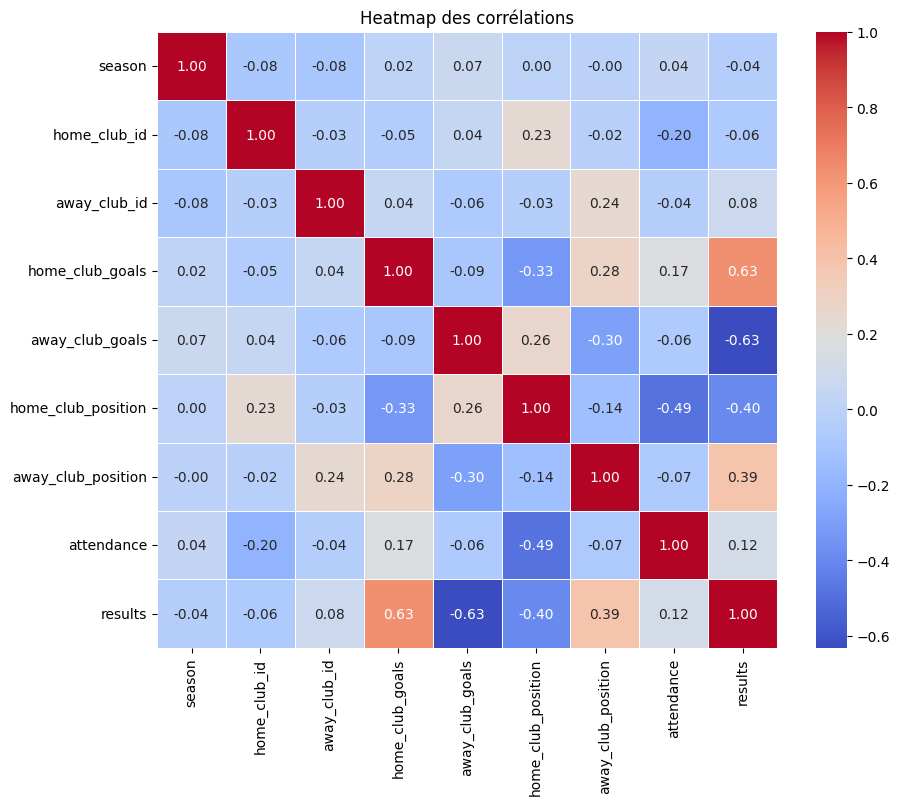

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('../data/brute/matchs_2013_2022.csv')

print(df.head())

colonnes_a_exclure = ['Unnamed: 0', 'game_id']

df_numeric = df.select_dtypes(include='number').drop(columns=colonnes_a_exclure)

corr_matrix = df_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Heatmap des corrélations')
plt.show()


Comme on peut le voir on voit évidemment une corrélation entre le nombre de buts de chaque équipe et le résultat. De plus, on voit également une certaine corrélation entre le classement et le nombre de spectateurs, le nombre de buts marqués et le résultat. On peut également observé une corrélation plus légère entre le nombre de spectateurs et le nombre de buts de l'équipe à domicile et le résultat.

Nous allons donc explorer ces liens éventuels avec différents graphe afin de dégager des pistes de variables à utiliser pour notre modèle de prédiction.

Nous allons commencer par voir l'impact de jouer à domicile ou à l'exterieur sur le résultat. On réalise donc un histogramme de la distribution des résultat des matchs.

C:\Users\chabo\AppData\Local\Temp\ipykernel_26648\1531052221.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='results', y='pourcentage', data=distribution_df, palette='Set2')


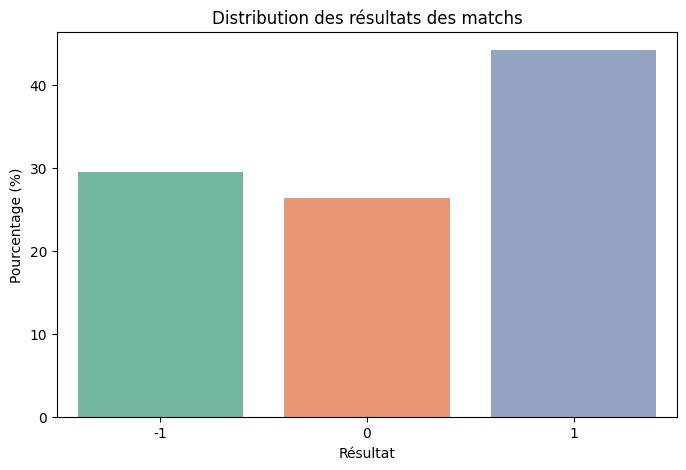

In [3]:
distribution = df['results'].value_counts(normalize=True) * 100

distribution_df = distribution.reset_index()
distribution_df.columns = ['results', 'pourcentage']

plt.figure(figsize=(8, 5))
sns.barplot(x='results', y='pourcentage', data=distribution_df, palette='Set2')
plt.title('Distribution des résultats des matchs')
plt.ylabel('Pourcentage (%)')
plt.xlabel('Résultat')
plt.show()

On peut voir l'équipe à domicile tend à gagner beaucoup plus souvent que l'équipe à l'exterieur dont la proportion est presque pareille à celle du nul. Le fait de jouer à domicile a donc effectivement un fort impact.

On analyse ensuite l'influence du classement sur le résultat du match pour les 2 équipes.

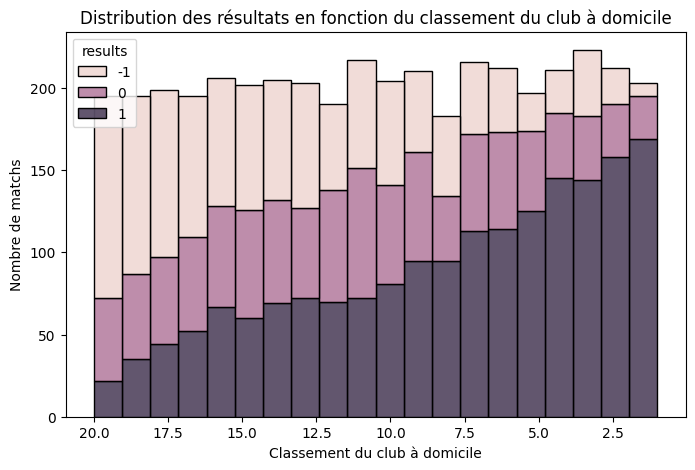

In [2]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="home_club_position", hue="results", multiple="stack", bins=20)

plt.gca().invert_xaxis()  

plt.title("Distribution des résultats en fonction du classement du club à domicile")
plt.xlabel("Classement du club à domicile")
plt.ylabel("Nombre de matchs")
plt.show()


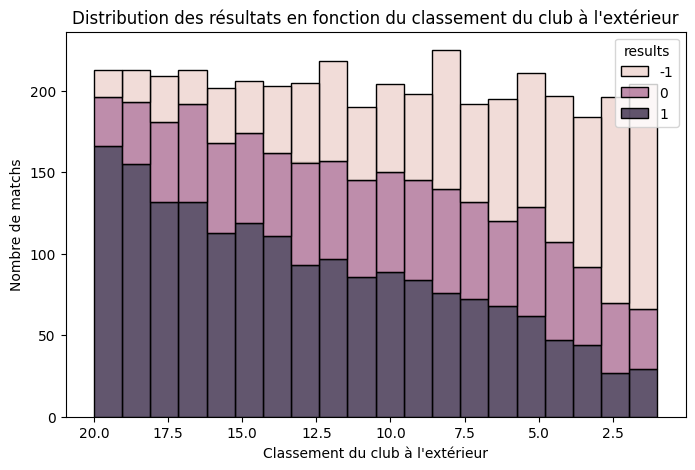

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x="away_club_position", hue="results", multiple="stack", bins=20)

plt.gca().invert_xaxis()  

plt.title("Distribution des résultats en fonction du classement du club à l'extérieur")
plt.xlabel("Classement du club à l'extérieur")
plt.ylabel("Nombre de matchs")
plt.show()


On voit donc bien que un club mieux classé a tendance à plus gagner même si le classement semble avoir plus d'influence sur le club à domicile que le club à l'exterieur du à ce que nous avons mis en avant précédemment.

Enfin, on peut également voir grâce au boxplot suivant que le nombre de buts du club exterieur est beaucoup plus étalé que le nombre de buts de l'équipe domicile.

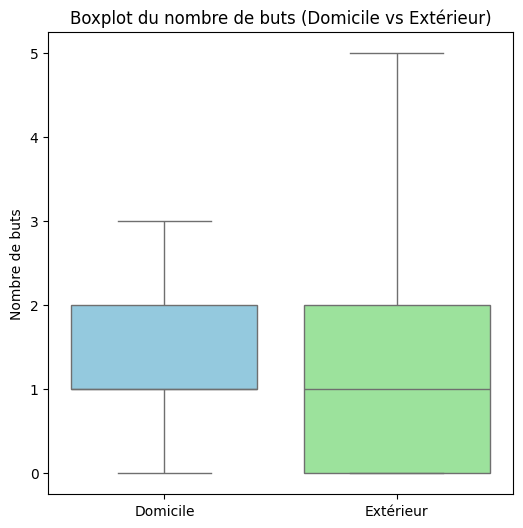

In [11]:
plt.figure(figsize=(6, 6))  


sns.boxplot(data=[df['home_club_goals'], df['away_club_goals']], palette=["skyblue", "lightgreen"],showfliers=False)
plt.xticks([0, 1], ['Domicile', 'Extérieur'])
plt.title('Boxplot du nombre de buts (Domicile vs Extérieur)')
plt.ylabel('Nombre de buts')

plt.show()

Malgré les liens mis en avant il est assez évident que nous disposons de trop peu d'éléments de prédictions. De plus, un certain nombre de ces variables sont inexploitables car elles portent sur la saison actuelle (comme le classement avant le match) alors que nous devons prédire à partir des saisons précédentes étant donné que nous ne possédons aucune donnée numérique pour 2023. Nous avons donc décidé de créer un certain nombre de colonnes dans un dataframe final contenant matchs_2023_2022 et les données intéressantes des autres csv.

On crée tout d'abord des colonnes de valeurs générales pour les 2 équipes comme le classement moyen sur les x dernières années étant donné qu'on ne disposera pas du classement avant le match, la différence de buts moyenne sur les x dernières années, le winrate sur les x dernières années etc...

On crée également des colonnes de différence sur ces memes valeurs, car il est parfois beaucoup plus intéressant d'observer la différence entre 2 équipes plutot que la valeur même.

On ajoute aussi des colonnes de confrontation afin de voir la dynamique entre ces 2 équipes spécifiquement, certaines équipes sont parfois rivales, ce qui change completement la physionomie des équipes et du match.

Enfin on ajoute des colonnes pour l'évolution de ces paramètres afin de voir si les équipes sont sur une pente ascendante ou descendante ce qui est intéressant pour comprendre l'évolution des équipes sur le long terme.

In [16]:
%load_ext autoreload
%autoreload 2
import importlib
import pandas as pd
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt
import sys
sys.path.append("../src/")
import nettoyage
importlib.reload(nettoyage)

<module 'nettoyage' from 'c:\\Users\\chabo\\Desktop\\winunmax\\Winunmax\\notebooks\\../src\\nettoyage.py'>

In [18]:
#Initialisation des dataframes à partir des .csv bruts

df_clubs = pd.read_csv("../data/brute/clubs_fr.csv")
df_composition_equipes = pd.read_csv("../data/brute/game_lineups.csv")
df_detail_matchs = pd.read_csv("../data/brute/game_events.csv")
df_cartons_joueurs = pd.read_csv("../data/brute/player_appearance.csv")
df_valeur_joueurs = pd.read_csv("../data/brute/player_valuation_before_season.csv")
df_resultat_matchs = pd.read_csv("../data/brute/matchs_2013_2022.csv")

C:\Users\chabo\AppData\Local\Temp\ipykernel_26648\2178884926.py:4: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  df_composition_equipes = pd.read_csv("../data/brute/game_lineups.csv")


In [19]:

df_valeur_joueurs["date"] = pd.to_datetime(df_valeur_joueurs["date"])
df_composition_equipes["date"] = pd.to_datetime(df_composition_equipes["date"])
df_resultat_matchs["date"] = pd.to_datetime(df_resultat_matchs["date"])
df_cartons_joueurs["date"] = pd.to_datetime(df_cartons_joueurs["date"])
df_detail_matchs["date"] = pd.to_datetime(df_detail_matchs["date"])

In [20]:
#Création d’un dataframe centralisé qui comporte plus d’information que df_resultat_matchs

df_dataset_final = df_resultat_matchs.copy()
#Garder les colonnes qui nous intéressent
df_dataset_final = df_dataset_final[["home_club_name","away_club_name","game_id","date","season","home_club_id","away_club_id","home_club_position","away_club_position","results","home_club_goals","away_club_goals"]]

#Ajout de la différence de classement
df_dataset_final["difference classement"] = df_dataset_final["home_club_position"]-df_dataset_final["away_club_position"]

#Ajout ratio valorisation home par away
df_dataset_final = nettoyage.calcul_difference_valorisation(df_dataset_final,df_composition_equipes,df_valeur_joueurs)
df_dataset_final = nettoyage.calcul_ratio_valorisation(df_dataset_final,df_composition_equipes,df_valeur_joueurs)
df_dataset_final = nettoyage.calcul_log_ratio_valorisation(df_dataset_final,df_composition_equipes,df_valeur_joueurs)

#Ajout winrate
nb_annes = 1
df_dataset_final = nettoyage.calcul_winrate_historique(df_dataset_final,nb_annes)
df_dataset_final["difference winrate home-away "+str(nb_annes)+" ans"] = df_dataset_final["winrate_home "+str(nb_annes)+" ans"]-df_dataset_final["winrate_away "+str(nb_annes)+" ans"]
nb_annes_ter = 2
df_dataset_final = nettoyage.calcul_winrate_historique(df_dataset_final,nb_annes_ter)
df_dataset_final["difference winrate home-away "+str(nb_annes_ter)+" ans"] = df_dataset_final["winrate_home "+str(nb_annes_ter)+" ans"]-df_dataset_final["winrate_away "+str(nb_annes_ter)+" ans"]
nb_annes_bis = 3
df_dataset_final = nettoyage.calcul_winrate_historique(df_dataset_final,nb_annes_bis)
df_dataset_final["difference winrate home-away "+str(nb_annes_bis)+" ans"] = df_dataset_final["winrate_home "+str(nb_annes_bis)+" ans"]-df_dataset_final["winrate_away "+str(nb_annes_bis)+" ans"]
#Ajout évolution de la différence de winrate entre les deux équipes entre long terme et court terme 
df_dataset_final["evolution difference winrate home-away entre "+str(nb_annes_bis)+" et "+str(nb_annes)+" ans"] = df_dataset_final["difference winrate home-away "+str(nb_annes)+" ans"] - df_dataset_final["difference winrate home-away "+str(nb_annes_bis)+" ans"]

#Ajout winrate confrontation
nb_annes = 1
df_dataset_final = nettoyage.ajout_winrate_confrontation_directe(df_dataset_final,nb_annes)
nb_annes_ter = 2
df_dataset_final = nettoyage.ajout_winrate_confrontation_directe(df_dataset_final,nb_annes_ter)
nb_annes_bis = 3
df_dataset_final = nettoyage.ajout_winrate_confrontation_directe(df_dataset_final,nb_annes_bis)

#Ajout classement moyen des dernières années
nb_annes = 1
df_dataset_final = nettoyage.ajout_classement_moyen_historique(df_dataset_final,nb_annes)
df_dataset_final["difference classement moyen home-away "+str(nb_annes)+" ans"] = df_dataset_final["pos_moy_home_"+str(nb_annes)+"_ans"]-df_dataset_final["pos_moy_away_"+str(nb_annes)+"_ans"]
nb_annes_ter = 2
df_dataset_final = nettoyage.ajout_classement_moyen_historique(df_dataset_final,nb_annes_ter)
df_dataset_final["difference classement moyen home-away "+str(nb_annes_ter)+" ans"] = df_dataset_final["pos_moy_home_"+str(nb_annes_ter)+"_ans"]-df_dataset_final["pos_moy_away_"+str(nb_annes_ter)+"_ans"]
nb_annes_bis = 3
df_dataset_final = nettoyage.ajout_classement_moyen_historique(df_dataset_final,nb_annes_bis)
df_dataset_final["difference classement moyen home-away "+str(nb_annes_bis)+" ans"] = df_dataset_final["pos_moy_home_"+str(nb_annes_bis)+"_ans"]-df_dataset_final["pos_moy_away_"+str(nb_annes_bis)+"_ans"]
#Ajout évolution de classement long terme - court terme
df_dataset_final["evolution classement home "+str(nb_annes_bis)+" et "+str(nb_annes)+" ans"] = df_dataset_final["pos_moy_home_"+str(nb_annes)+"_ans"] - df_dataset_final["pos_moy_home_"+str(nb_annes_bis)+"_ans"]
df_dataset_final["evolution classement away "+str(nb_annes_bis)+" et "+str(nb_annes)+" ans"] = df_dataset_final["pos_moy_away_"+str(nb_annes)+"_ans"] - df_dataset_final["pos_moy_away_"+str(nb_annes_bis)+"_ans"]

#Ajout évolution de la différence de classement entre les deux équipes entre long terme et court terme 
df_dataset_final["evolution difference classement entre équipes entre "+str(nb_annes_bis)+" et "+str(nb_annes)+" ans"] = df_dataset_final["difference classement moyen home-away "+str(nb_annes)+" ans"] - df_dataset_final["difference classement moyen home-away "+str(nb_annes_bis)+" ans"]

#Ajout de la nouveauté d’un club dans la ligue
#df_dataset_final = nettoyage.ajout_bool_nouveau_club(df_dataset_final)
df_dataset_final = nettoyage.ajout_bool_nouveau_club_multi_annees(df_dataset_final,1)
df_dataset_final = nettoyage.ajout_bool_nouveau_club_multi_annees(df_dataset_final,3)

#Ajout de la différence de but moyenne
nb_annes = 1
df_dataset_final = nettoyage.ajout_diffbut_moyen_historique(df_dataset_final,nb_annes)
df_dataset_final["difference de buts moyenne home-away "+str(nb_annes)+" ans"]= df_dataset_final["diffbut_moy_home_"+str(nb_annes)+"_ans"]-df_dataset_final["diffbut_moy_away_"+str(nb_annes)+"_ans"]
nb_annes_ter = 2
df_dataset_final = nettoyage.ajout_diffbut_moyen_historique(df_dataset_final,nb_annes_ter)
df_dataset_final["difference de buts moyenne home-away "+str(nb_annes_ter)+" ans"]= df_dataset_final["diffbut_moy_home_"+str(nb_annes_ter)+"_ans"]-df_dataset_final["diffbut_moy_away_"+str(nb_annes_ter)+"_ans"]
nb_annes_bis = 3
df_dataset_final = nettoyage.ajout_diffbut_moyen_historique(df_dataset_final,nb_annes_bis)
df_dataset_final["difference de buts moyenne home-away "+str(nb_annes_bis)+" ans"]= df_dataset_final["diffbut_moy_home_"+str(nb_annes_bis)+"_ans"]-df_dataset_final["diffbut_moy_away_"+str(nb_annes_bis)+"_ans"]   

#Ajout évolution de la différence de but long terme - court terme
df_dataset_final["evolution difference de buts home "+str(nb_annes_bis)+" et "+str(nb_annes)+" ans"] = df_dataset_final["diffbut_moy_home_"+str(nb_annes)+"_ans"] - df_dataset_final["diffbut_moy_home_"+str(nb_annes_bis)+"_ans"]
df_dataset_final["evolution difference de buts away "+str(nb_annes_bis)+" et "+str(nb_annes)+" ans"] = df_dataset_final["diffbut_moy_away_"+str(nb_annes)+"_ans"] - df_dataset_final["diffbut_moy_away_"+str(nb_annes_bis)+"_ans"]

#Ajout évolution de la différence de buts entre les deux équipes entre long terme et court terme 
df_dataset_final["evolution difference de buts entre équipes entre "+str(nb_annes_bis)+" et "+str(nb_annes)+" ans"] = df_dataset_final["difference de buts moyenne home-away "+str(nb_annes)+" ans"] - df_dataset_final["difference de buts moyenne home-away "+str(nb_annes_bis)+" ans"]

#Ajout différence de but moyenne confrontation
nb_annes = 1
df_dataset_final = nettoyage.ajout_diffbut_moyenne_confrontation_historique(df_dataset_final,nb_annes)
nb_annes_ter = 2
df_dataset_final = nettoyage.ajout_diffbut_moyenne_confrontation_historique(df_dataset_final,nb_annes_ter)
nb_annes_bis = 3
df_dataset_final = nettoyage.ajout_diffbut_moyenne_confrontation_historique(df_dataset_final,nb_annes_bis)

df_dataset_final = df_dataset_final.drop(columns=["away_club_goals","home_club_goals"])
display(df_dataset_final.tail(3))

,home_club_name,away_club_name,game_id,date,season,home_club_id,away_club_id,home_club_position,away_club_position,results,...,difference de buts moyenne home-away 2 ans,diffbut_moy_home_3_ans,diffbut_moy_away_3_ans,difference de buts moyenne home-away 3 ans,evolution difference de buts home 3 et 1 ans,evolution difference de buts away 3 et 1 ans,evolution difference de buts entre équipes entre 3 et 1 ans,diffbut_moy_confrontation_1_ans,diffbut_moy_confrontation_2_ans,diffbut_moy_confrontation_3_ans
4075,Toulouse Football Club,Racing Club de Strasbourg Alsace,3047720,2019-01-13,2018,415,667,14.0,8.0,-1,...,0.342105,-0.263158,-0.605263,0.342105,-0.157895,0.000000,-0.157895,-0.5,-0.5,-0.5
4076,Association sportive de Monaco Football Club,Racing Club de Strasbourg Alsace,3199559,2020-01-25,2019,162,667,13.0,8.0,-1,...,0.447368,0.850877,-0.171053,1.021930,-1.350877,0.434211,-1.785088,-2.5,0.0,0.0
4077,FC Girondins Bordeaux,Stade brestois 29,3394685,2020-12-06,2020,40,3911,10.0,12.0,1,...,0.076840,0.028846,-0.107143,0.135989,0.185440,0.000000,0.185440,0.0,0.0,0.0


In [21]:
df_dataset_final_affichage_cor = df_dataset_final.copy().drop(columns=["game_id","season","home_club_id","away_club_id"])
df_dataset_final_affichage_cor.corr(numeric_only=True)['results'].sort_values(ascending=False)

results                                                           1.000000
away_club_position                                                0.392833
difference winrate home-away 3 ans                                0.303177
difference winrate home-away 2 ans                                0.301032
difference de buts moyenne home-away 3 ans                        0.297534
difference de buts moyenne home-away 2 ans                        0.291887
difference winrate home-away 1 ans                                0.290827
LOG Ratio value home par away                                     0.289665
difference de buts moyenne home-away 1 ans                        0.282487
Difference value home et away                                     0.222252
diffbut_moy_home_3_ans                                            0.209099
diffbut_moy_home_1_ans                                            0.203600
diffbut_moy_confrontation_3_ans                                   0.201601
diffbut_moy_home_2_ans   

In [22]:
df_dataset_final.to_csv("../data/preparee/dataframe_traite.csv", index=False)

df_dataset_final_sans_2012 = df_dataset_final[df_dataset_final["season"]!=2012].copy()
df_dataset_final_sans_2012.to_csv("../data/preparee/dataframe_traite_sans_2012.csv", index=False)

df_dataset_final_sans_2012_13_14 = df_dataset_final[~df_dataset_final["season"].isin([2012,2013,2014])].copy()
df_dataset_final_sans_2012_13_14.to_csv("../data/preparee/dataframe_traite_sans_2012_13_14.csv", index=False)


df_dataset_final_nettoye_1 = df_dataset_final.copy().drop(columns=["difference winrate home-away 2 ans","difference de buts moyenne home-away 2 ans","Difference value home et away","diffbut_moy_home_2_ans","diffbut_moy_confrontation_2_ans","diffbut_moy_confrontation_1_ans","Ratio value home par away","winrate_home 2 ans","pos_moy_away_2_ans","winrate_confrontation_home 2 ans","winrate_confrontation_home 1 ans",
                                                                   "evolution classement away 3 et 1 ans","evolution classement home 3 et 1 ans","evolution difference de buts entre équipes entre 3 et 1 ans","evolution difference de buts away 3 et 1 ans","evolution difference de buts home 3 et 1 ans","pos_moy_home_2_ans","winrate_away 2 ans","diffbut_moy_away_2_ans","difference classement moyen home-away 2 ans"])
df_dataset_final_nettoye_1.to_csv("../data/preparee/dataframe_traite_nettoye_1.csv", index=False)

In [27]:
for col in df_dataset_final_sans_2012.columns:
    print(col)


home_club_name
away_club_name
game_id
date
season
home_club_id
away_club_id
home_club_position
away_club_position
results
difference classement
Difference value home et away
Ratio value home par away
home_team_value
away_team_value
LOG Ratio value home par away
winrate_home 1 ans
winrate_away 1 ans
difference winrate home-away 1 ans
winrate_home 2 ans
winrate_away 2 ans
difference winrate home-away 2 ans
winrate_home 3 ans
winrate_away 3 ans
difference winrate home-away 3 ans
evolution difference winrate home-away entre 3 et 1 ans
winrate_confrontation_home 1 ans
winrate_confrontation_home 2 ans
winrate_confrontation_home 3 ans
pos_moy_home_1_ans
pos_moy_away_1_ans
difference classement moyen home-away 1 ans
pos_moy_home_2_ans
pos_moy_away_2_ans
difference classement moyen home-away 2 ans
pos_moy_home_3_ans
pos_moy_away_3_ans
difference classement moyen home-away 3 ans
evolution classement home 3 et 1 ans
evolution classement away 3 et 1 ans
evolution difference classement entre équipe

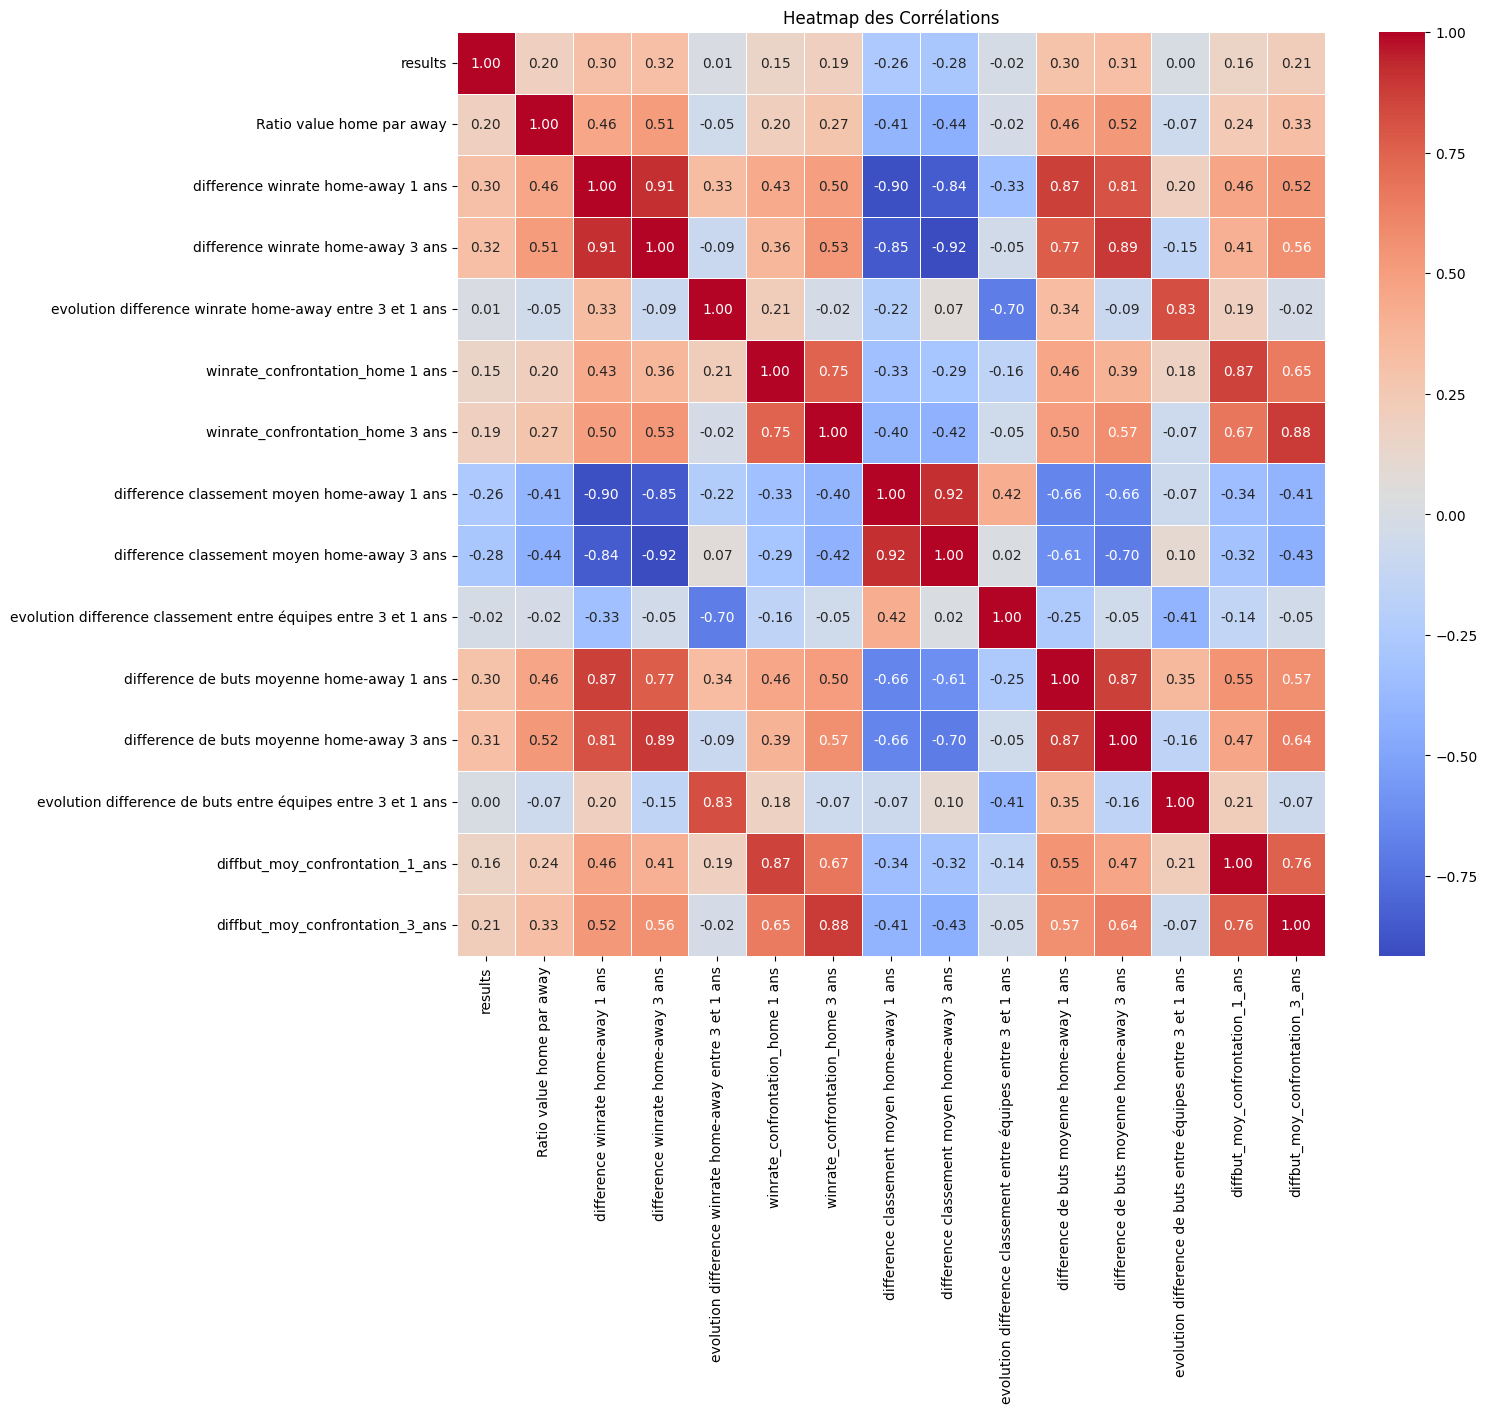

In [29]:

colonnes_heatmap = [
    'results','Ratio value home par away','difference winrate home-away 1 ans','difference winrate home-away 3 ans', 
    'evolution difference winrate home-away entre 3 et 1 ans','winrate_confrontation_home 1 ans', 
    'winrate_confrontation_home 3 ans','difference classement moyen home-away 1 ans',
    'difference classement moyen home-away 3 ans', 'evolution difference classement entre équipes entre 3 et 1 ans',
    'difference de buts moyenne home-away 1 ans','difference de buts moyenne home-away 3 ans',  
    'evolution difference de buts entre équipes entre 3 et 1 ans',
    'diffbut_moy_confrontation_1_ans', 'diffbut_moy_confrontation_3_ans'
]

corr_matrix = df_dataset_final_sans_2012[colonnes_heatmap].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Heatmap des Corrélations')
plt.show()
